# 메일 분류
## 라이브러리 설치

In [1]:
# !pip install konlpy wordcloud scikit-learn

## 분석기 로드

In [2]:
from konlpy.tag import Okt, Komoran, Kkma, Hannanum

okt      = Okt()
komoran  = Komoran()
kkma     = Kkma()
hannanum = Hannanum()

print("분석기 로드 완료")

분석기 로드 완료


## 카테고리 키워드

In [3]:
CATEGORIES = {
    "업무협조": ["요청", "협조", "부탁", "전달", "회신", "확인", "처리", "검토", "승인", "진행", "일정 요청", "자료 요청", "확인 부탁"],
    "보고서":   ["보고", "결과", "분석", "현황", "매출", "데이터", "통계", "성과", "개선", "지표", "리포트", "요약"],
    "회의록":   ["회의", "안건", "참석자", "일정", "논의", "결정", "진행", "회의록", "회의 결과", "액션 아이템"],
    "공지":     ["공지", "안내", "변경", "공지사항", "배포", "적용", "공지드립니다", "참고"],
}

## 불용어

In [4]:
STOPWORDS = set([
    "합니다", "있습니다", "드립니다", "바랍니다", "부탁드립니다",
    "안녕하세요", "감사합니다", "첨부파일", "확인", "관련", "내용",
    "진행", "경우", "이번", "해당", "통해", "위해", "대해",
])

## 명사 추출 함수

In [5]:
def extract_nouns(text, analyzer):
    if not text or not text.strip():  # 빈 텍스트 처리
        return []
    try:
        nouns = analyzer.nouns(text)
        nouns = [n for n in nouns if len(n) >= 2]
        nouns = [n for n in nouns if n not in STOPWORDS]
        return nouns
    except Exception as e:
        # print(f"⚠️ 추출 실패: {e}")
        return []

# 간단 테스트
sample = "업무협조 요청드립니다. 첨부파일 검토 후 회신 부탁드립니다."

print("=== 분석기별 명사 추출 결과 ===")
print(f"Okt      : {extract_nouns(sample, okt)}")
print(f"Komoran  : {extract_nouns(sample, komoran)}")
print(f"Kkma     : {extract_nouns(sample, kkma)}")
print(f"Hannanum : {extract_nouns(sample, hannanum)}")

=== 분석기별 명사 추출 결과 ===
Okt      : ['업무', '협조', '요청', '검토', '회신']
Komoran  : ['업무', '협조', '요청', '첨부', '파일', '검토', '회신', '부탁']
Kkma     : ['업무', '업무협조', '협조', '요청', '첨부', '파일', '검토', '회신', '부탁']
Hannanum : ['업무협조', '요청드', '첨부파', '검토']


## 액션 / 기한 / 요약 추출 함수

In [6]:
import re

ACTION_KEYWORDS = [
    "부탁드립니다", "확인 바랍니다", "회신 바랍니다",
    "검토 부탁", "처리 부탁", "승인 요청", "확인 부탁", "회신바랍니다"
]

DEADLINE_PATTERNS = [
    r"\d+일\s*내",
    r"\d{1,2}월\s*\d{1,2}일까지",
    r"\d{4}-\d{2}-\d{2}까지",
    r"\d+/\d+\s*\(.*?\)까지",
    r"\d+/\d+까지",
    r"오늘\s*중",
    r"내일까지",
    r"금주\s*내",
    r"이번\s*주\s*내",
    r"긴급|즉시|빠른\s*시일",
]

def detect_action(text):
    return any(kw in text for kw in ACTION_KEYWORDS)

def find_deadline(text):
    for pattern in DEADLINE_PATTERNS:
        m = re.search(pattern, text)
        if m:
            return m.group(0)
    return "-"

def make_summary(body):
    sentences = [s.strip() for s in re.split(r'[.\n]', body) if len(s.strip()) > 5]
    return " / ".join(sentences[:2]) if sentences else "-"

## 1. KoNLPy + FreqDist 키워드 빈도

### FreqDist 기반 분류 함수

In [7]:
from nltk import FreqDist

def classify_freqdist(text, analyzer):
    """
    명사 추출 → FreqDist 빈도 분석
    → 카테고리 키워드와 겹치는 빈도 합산
    → 가장 높은 카테고리로 분류
    """
    nouns = extract_nouns(text, analyzer)
    if not nouns:
        return "기타", 0.0

    fd = FreqDist(nouns)

    # 카테고리별 키워드 빈도 합산
    scores = {}
    for cat, keywords in CATEGORIES.items():
        scores[cat] = sum(fd[kw] for kw in keywords)

    total = sum(scores.values())
    if total == 0:
        return "기타", 0.0

    best = max(scores, key=scores.get)
    confidence = round(scores[best] / total, 2)
    return best, confidence

### 분석기 비교

In [8]:
import time
import json

ANALYZERS = {
    "Okt":      okt,
    "Komoran":  komoran,
    "Kkma":     kkma,
    "Hannanum": hannanum,
}


with open("results.json", "r", encoding="utf-8") as f:
    results = json.load(f)

print(f" {len(results)}건 로드 완료")

freqdist_results = {}

for name, analyzer in ANALYZERS.items():
    print(f" [FreqDist] {name} 분석 중...")
    start = time.time()
    rows = []

    for r in results:
        subject   = r["subject"]
        sender    = r.get("sender", "")   
        body      = r["body"]
        pdf_text  = r["pdf_text"]
        full_text = subject + " " + body + " " + pdf_text

        cat1, conf1 = classify_freqdist(subject, analyzer)  # or classify_tfidf
        cat2, conf2 = classify_freqdist(subject + " " + body, analyzer)
        cat3, conf3 = classify_freqdist(subject + " " + body + " " + pdf_text, analyzer)

        rows.append({
            "제목":             subject,
            "발신자":           sender,              
            "분류_제목":        cat1,
            "신뢰도_제목":      conf1,
            "분류_제목+본문":   cat2,
            "신뢰도_제목+본문": conf2,
            "분류_전체":        cat3,
            "신뢰도_전체":      conf3,
            "액션필요":         detect_action(full_text),   
            "기한":             find_deadline(full_text),   
            "요약":             make_summary(body),         
        })

    elapsed = round(time.time() - start, 2)
    freqdist_results[name] = {"rows": rows, "time": elapsed}
    print(f" {name} 완료 ({elapsed}초)")

 13건 로드 완료
 [FreqDist] Okt 분석 중...
 Okt 완료 (0.45초)
 [FreqDist] Komoran 분석 중...
 Komoran 완료 (0.6초)
 [FreqDist] Kkma 분석 중...
 Kkma 완료 (1.84초)
 [FreqDist] Hannanum 분석 중...
 Hannanum 완료 (1.03초)


## 2. KoNLPy + TF-IDF 키워드 빈도
###  TF-IDF 기반 분류 함수

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def classify_tfidf(text, analyzer):
    """
    명사 추출 → TF-IDF 수치화
    → 카테고리 키워드와 단어 가중치 비교
    → 가장 높은 카테고리로 분류
    """
    nouns = extract_nouns(text, analyzer)
    if not nouns:
        return "기타", 0.0

    input_doc = " ".join(nouns)

    # 카테고리별 키워드 문서
    category_docs = {cat: " ".join(kws) for cat, kws in CATEGORIES.items()}

    # TF-IDF 벡터화
    docs = [input_doc] + list(category_docs.values())
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(docs)

    # 입력 텍스트의 TF-IDF 벡터
    input_vec = tfidf_matrix[0].toarray()[0]

    # 카테고리별 키워드 가중치 합산
    feature_names = vectorizer.get_feature_names_out()
    scores = {}
    for i, (cat, kws) in enumerate(CATEGORIES.items()):
        score = sum(
            input_vec[np.where(feature_names == kw)[0][0]]
            for kw in kws
            if kw in feature_names
        )
        scores[cat] = score

    total = sum(scores.values())
    if total == 0:
        return "기타", 0.0

    best = max(scores, key=scores.get)
    confidence = round(scores[best] / total, 2)
    return best, confidence

### 분석기 비교

In [10]:
tfidf_results = {}

for name, analyzer in ANALYZERS.items():
    print(f"⏳ [TF-IDF] {name} 분석 중...")
    start = time.time()
    rows = []

    for r in results:
        subject   = r["subject"]
        sender    = r.get("sender", "")   
        body      = r["body"]
        pdf_text  = r["pdf_text"]
        full_text = subject + " " + body + " " + pdf_text

        cat1, conf1 = classify_freqdist(subject, analyzer)  # or classify_tfidf
        cat2, conf2 = classify_freqdist(subject + " " + body, analyzer)
        cat3, conf3 = classify_freqdist(subject + " " + body + " " + pdf_text, analyzer)

        rows.append({
            "제목":             subject,
            "발신자":           sender,              
            "분류_제목":        cat1,
            "신뢰도_제목":      conf1,
            "분류_제목+본문":   cat2,
            "신뢰도_제목+본문": conf2,
            "분류_전체":        cat3,
            "신뢰도_전체":      conf3,
            "액션필요":         detect_action(full_text),   
            "기한":             find_deadline(full_text),   
            "요약":             make_summary(body),         
        })

    elapsed = round(time.time() - start, 2)
    tfidf_results[name] = {"rows": rows, "time": elapsed}
    print(f"✅ {name} 완료 ({elapsed}초)")

⏳ [TF-IDF] Okt 분석 중...
✅ Okt 완료 (0.23초)
⏳ [TF-IDF] Komoran 분석 중...
✅ Komoran 완료 (0.08초)
⏳ [TF-IDF] Kkma 분석 중...
✅ Kkma 완료 (1.35초)
⏳ [TF-IDF] Hannanum 분석 중...
✅ Hannanum 완료 (0.72초)


##  FreqDist와 TF-IDF 비교

In [11]:
import pandas as pd

def make_summary(result_dict, method_name):
    rows = []
    for name, data in result_dict.items():
        df = pd.DataFrame(data["rows"])
        same_1 = (df["분류_제목"] == df["분류_전체"]).mean()
        same_2 = (df["분류_제목+본문"] == df["분류_전체"]).mean()
        rows.append({
            "방법":             method_name,
            "분석기":           name,
            "신뢰도_제목":      f"{df['신뢰도_제목'].mean():.2%}",
            "신뢰도_제목+본문": f"{df['신뢰도_제목+본문'].mean():.2%}",
            "신뢰도_전체":      f"{df['신뢰도_전체'].mean():.2%}",
            "일치율_제목":      f"{same_1:.2%}",
            "일치율_제목+본문": f"{same_2:.2%}",
            "처리시간(초)":     data["time"],
        })
    return rows

summary = make_summary(freqdist_results, "FreqDist") + \
          make_summary(tfidf_results,    "TF-IDF")

summary_df = pd.DataFrame(summary)
summary_df

,방법,분석기,신뢰도_제목,신뢰도_제목+본문,신뢰도_전체,일치율_제목,일치율_제목+본문,처리시간(초)
0,FreqDist,Okt,61.15%,55.46%,57.08%,84.62%,76.92%,0.45
1,FreqDist,Komoran,57.31%,37.54%,38.92%,84.62%,84.62%,0.60
2,FreqDist,Kkma,57.31%,52.31%,51.23%,84.62%,76.92%,1.84
3,FreqDist,Hannanum,51.31%,55.23%,57.38%,76.92%,84.62%,1.03
4,TF-IDF,Okt,61.15%,55.46%,57.08%,84.62%,76.92%,0.23
5,TF-IDF,Komoran,57.31%,37.54%,38.92%,84.62%,84.62%,0.08
6,TF-IDF,Kkma,57.31%,52.31%,51.23%,84.62%,76.92%,1.35
7,TF-IDF,Hannanum,51.31%,55.23%,57.38%,76.92%,84.62%,0.72


## 시각화

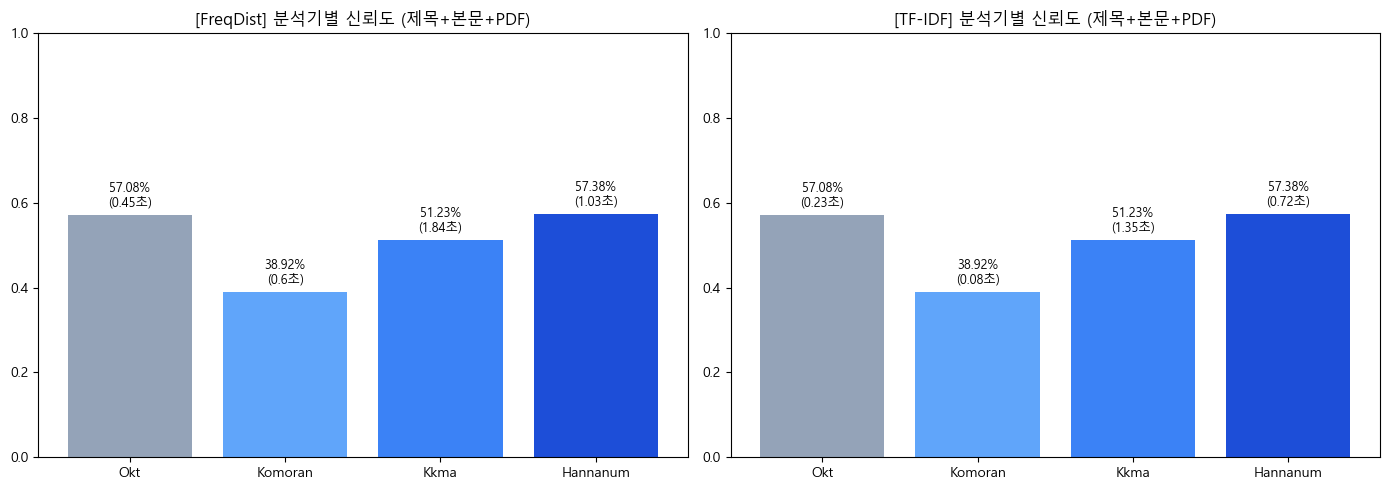

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import os 

# matplotlib.rcParams["font.family"] = "AppleGothic"   # Mac
matplotlib.rcParams["font.family"] = "Malgun Gothic"  # Windows
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["font.family"] = "Malgun Gothic"  # Windows

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (method, result_dict) in zip(axes, [
    ("FreqDist", freqdist_results),
    ("TF-IDF",   tfidf_results),
]):
    names      = list(result_dict.keys())
    conf_full  = [pd.DataFrame(d["rows"])["신뢰도_전체"].mean() for d in result_dict.values()]
    times      = [d["time"] for d in result_dict.values()]

    x = np.arange(len(names))
    bars = ax.bar(x, conf_full, color=["#94a3b8", "#60a5fa", "#3b82f6", "#1d4ed8"])
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title(f"[{method}] 분석기별 신뢰도 (제목+본문+PDF)")
    ax.set_ylim(0, 1)

    for i, (v, t) in enumerate(zip(conf_full, times)):
        ax.text(i, v + 0.02, f"{v:.2%}\n({t}초)", ha="center", fontsize=9)

os.makedirs("results", exist_ok=True)
plt.tight_layout()
plt.savefig("results/method_compare.png", dpi=150)
plt.show()

## FreqDist TOP20 키워드

In [13]:
from nltk import FreqDist

all_nouns = []
for r in results:
    full_text = r["subject"] + " " + r["body"] + " " + r["pdf_text"]
    all_nouns.extend(extract_nouns(full_text, komoran))  # 결과 좋은 분석기로 교체

fd = FreqDist(all_nouns)
print("=== TOP 20 키워드 ===")
for word, count in fd.most_common(20):
    print(f"{word:10} : {count}회")

=== TOP 20 키워드 ===
분석         : 28회
데이터        : 27회
요청         : 27회
검토         : 25회
사항         : 19회
기능         : 19회
일정         : 18회
고객         : 16회
시스템        : 14회
증가         : 12회
결과         : 11회
서버         : 11회
회의         : 11회
보고서        : 10회
사용자        : 10회
개선         : 10회
검증         : 10회
서비스        : 9회
필요         : 9회
영향         : 9회


## 카테고리별 wordcloud

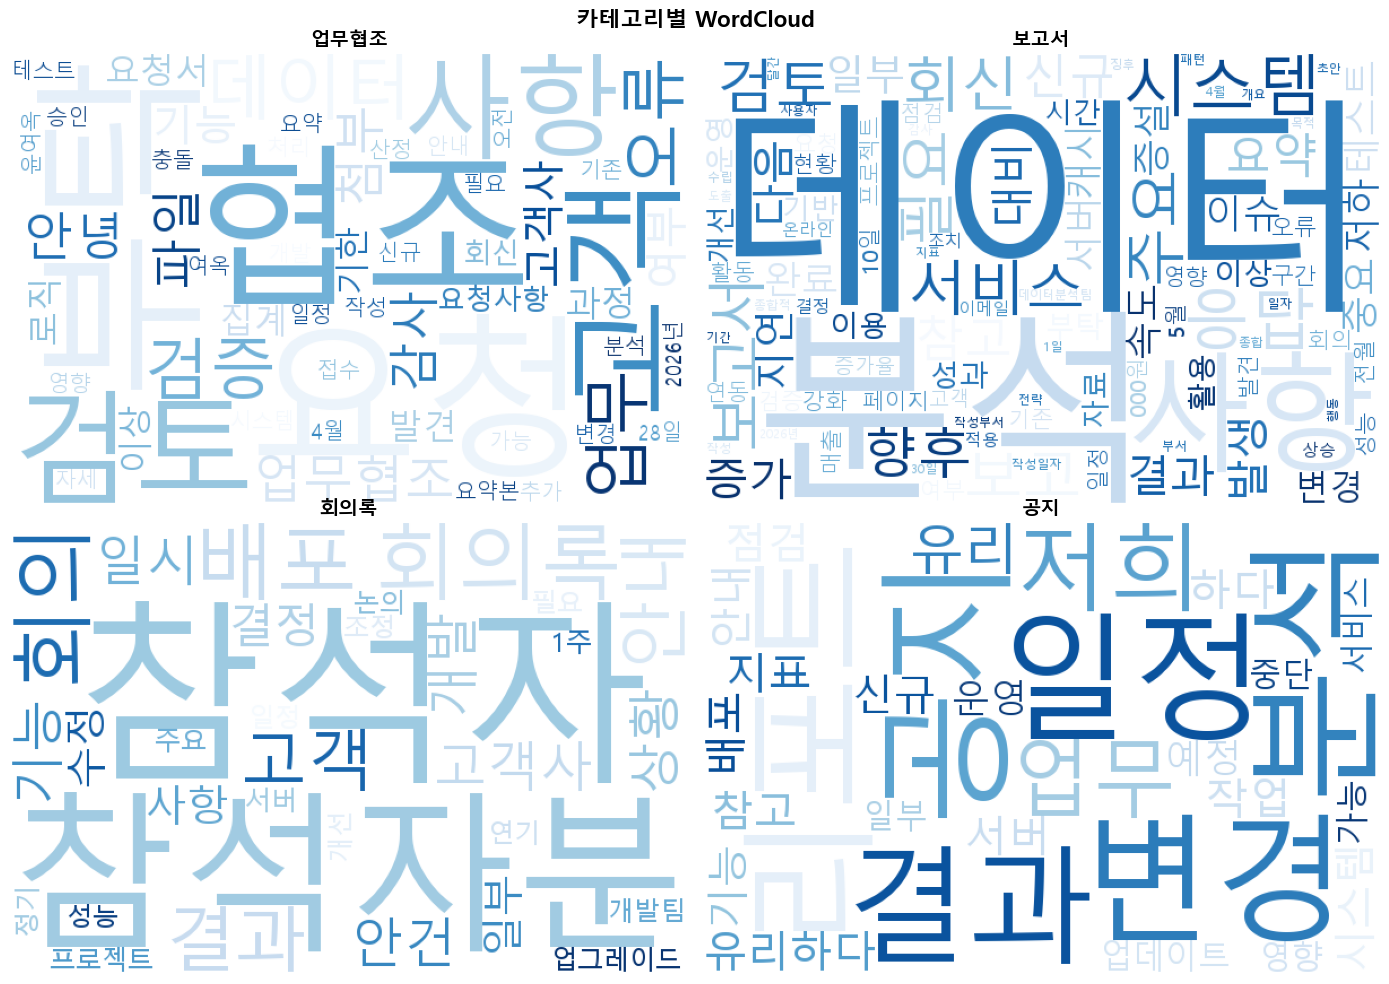

In [14]:
from wordcloud import WordCloud

font_path = "C:/Windows/Fonts/malgun.ttf"        # Windows
# font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"  # Mac

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cat in enumerate(CATEGORIES.keys()):
    cat_texts = [
        r["subject"] + " " + r["body"] + " " + r["pdf_text"]
        for r, res in zip(results, pd.DataFrame(
            freqdist_results["Kkma"]["rows"]  # 신뢰도 높은 분석기 사용
        ).to_dict("records"))
        if res["분류_전체"] == cat
    ]

    if not cat_texts:
        axes[i].set_title(f"{cat} (데이터 없음)")
        axes[i].axis("off")
        continue

    nouns = []
    for t in cat_texts:
        nouns.extend(extract_nouns(t, kkma))

    wc = WordCloud(
        font_path=font_path,
        background_color="white",
        max_words=100,
        width=600,
        height=400,
        colormap="Blues",
    ).generate(" ".join(nouns))

    axes[i].imshow(wc)
    axes[i].set_title(cat, fontsize=14, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("카테고리별 WordCloud", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("results/wordcloud.png", dpi=150)
plt.show()

## 결과 저장

In [ ]:
import json

final_results = freqdist_results["Kkma"]["rows"]

with open("final_results.json", "w", encoding="utf-8") as f:
    json.dump(final_results, f, ensure_ascii=False, indent=2)

print("✅ final_results.json 저장 완료")

# 커널 종료 ✅
import IPython
IPython.core.getipython.get_ipython().kernel.do_shutdown(restart=False)